# ArchR-style Iterative LSI


`epione.tl.iterative_lsi` ports ArchR's `addIterativeLSI` (TF–log(IDF) + randomized SVD with cluster-guided variable-feature refinement + depth-correlation filtering). It runs directly on a peak or tile AnnData — no ArchR project required — and writes the embedding to `adata.obsm['X_iterative_lsi']`.


## Data Preparation

We use snapatac2's bundled pbmc5k fragment file so the tutorial is self-contained. If you're starting from your own fragments, go through `epi.pp.import_fragments` (see `t_integrate`) and skip to the `iterative_lsi` step.


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, pathlib
os.environ['XDG_CACHE_HOME'] = '/scratch/users/steorra/cache'

import numpy as np
import pandas as pd
import anndata as ad
import anndataoom as oom
import scanpy as sc
import epione as epi
import matplotlib.pyplot as plt

epi.pl.plot_set()

WORK = pathlib.Path('/scratch/users/steorra/data/pbmc5k_iter_lsi')
WORK.mkdir(parents=True, exist_ok=True)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



### Build a tile matrix from fragments

`snap.pp.import_fragments` → QC → `add_tile_matrix(bin_size=5000)` → `select_features`. Same pattern as the snapatac2 quick-start.


In [2]:
%%time
h5 = WORK / 'pbmc5k.h5ad'
if h5.exists() and h5.stat().st_size > 100_000:
    data = oom.read(str(h5), backed='r+')
else:
    if h5.exists():
        h5.unlink()
    frag = epi.utils.register_datasets().fetch('atac_pbmc_5k.tsv.gz')
    data = epi.pp.import_fragments(
        str(frag),
        chrom_sizes=epi.utils.genome.hg38,
        file=str(h5),
        sorted_by_barcode=False,
    )
    genes = epi.utils.get_gene_annotation(epi.utils.genome.hg38)
    epi.pp.tsse(data, genes)
    data = epi.pp.filter_cells(data, min_counts=1000, max_counts=100000, min_tsse=5)
    epi.pp.add_tile_matrix(data, bin_size=5000)
    epi.pp.select_features(data, n_features=100000)
data


CPU times: user 1 s, sys: 1.05 s, total: 2.05 s
Wall time: 2.06 s


name,dtype,preview
n_fragment,uint64,"22067, 10498, 19191, … (4657)"
frac_dup,float64,"0.5219143358537166, 0.5345186893096262, 0.5101962685995763, … (5165)"
frac_mito,float64,0.0
tsse,float64,"31.70564634504355, 29.54060864508625, 17.706611570247937, … (5027)"
name,dtype,preview
count,float64,"0.0, 15.0, 3.0, … (6370)"
selected,bool,"False, True"
key,shape,dtype
fragment_paired,"(5166, 3088286401)",uint32


### Convert to an in-memory AnnData

`iterative_lsi` operates on a standard AnnData; snapatac2's on-disk store needs to be materialized first.


In [3]:
# Materialise the anndataoom BackedArray to an in-memory AnnData
# (scanpy / plotting expect a plain AnnData).
from scipy import sparse
parts = []
for _, _, ch in data.X.chunked():
    parts.append(ch)
if sparse.issparse(parts[0]):
    X = sparse.vstack(parts).tocsr()
else:
    X = sparse.csr_matrix(np.vstack(parts))

obs = pd.DataFrame(data.obs).copy()
obs.index = list(data.obs_names)
var = pd.DataFrame(data.var).copy()
var.index = list(data.var_names)
adata = ad.AnnData(X=X, obs=obs, var=var)
adata.obs['n_fragment'] = np.asarray(adata.X.sum(axis=1)).ravel()

if 'selected' in adata.var.columns:
    adata = adata[:, adata.var['selected'].astype(bool).values].copy()
adata


AnnData object with n_obs × n_vars = 5166 × 100000
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    var: 'count', 'selected'

## Iterative LSI

Two-round iterative LSI, ArchR defaults: 25k variable features per iteration, 30 components, depth-correlated components dropped (`|r|>0.75`). Pre-sampling to 10k cells in the first round keeps peak memory bounded on larger datasets.


In [4]:
%%time
epi.tl.iterative_lsi(
    adata,
    n_components=30,
    iterations=2,
    var_features=25_000,
    resolution=0.5,
    n_neighbors=30,
    sample_cells_pre=10_000,
    depth_col='n_fragment',
    cor_cut_off=0.75,
    seed=1,
)
adata.obsm['X_iterative_lsi'].shape


  └─ [iterative_lsi] Initial feature set: 99,500 / 100,000


  └─ [iterative_lsi] Iter 1/2 | fit on 5,166 cells x 99,500 features


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:32)


running Leiden clustering


    finished: found 13 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


  └─ [iterative_lsi]   -> 13 clusters; selected 25,000 variable features for next round


  └─ [iterative_lsi] Iter 2/2 | fit on 5,166 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (5,166 x 29) in adata.obsm['X_iterative_lsi']
CPU times: user 2min 1s, sys: 3.24 s, total: 2min 5s
Wall time: 56.2 s


(5166, 29)

In [5]:
adata.uns['X_iterative_lsi']['kept_dims']


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], dtype=int32)

## Clustering and UMAP


In [6]:
%%time
sc.pp.neighbors(adata, use_rep='X_iterative_lsi', n_neighbors=30)
sc.tl.leiden(adata, resolution=0.5, flavor='igraph',
             directed=False, n_iterations=2, random_state=0,
             key_added='leiden')
sc.tl.umap(adata, random_state=0)
adata.obs['leiden'].nunique()


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)


running Leiden clustering


    finished: found 10 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:13)


CPU times: user 23.4 s, sys: 135 ms, total: 23.5 s
Wall time: 15.3 s


10

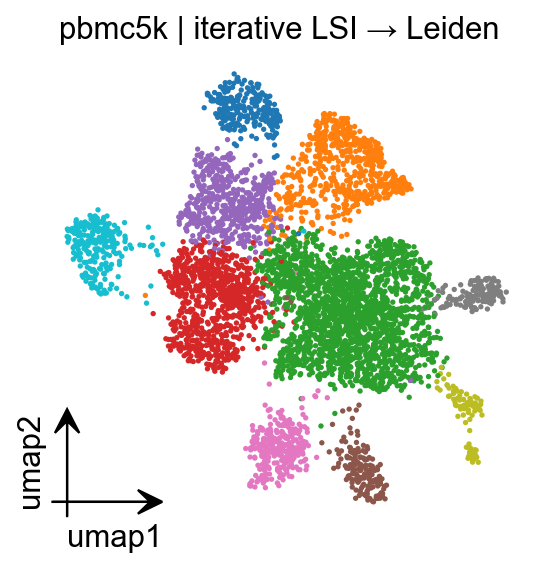

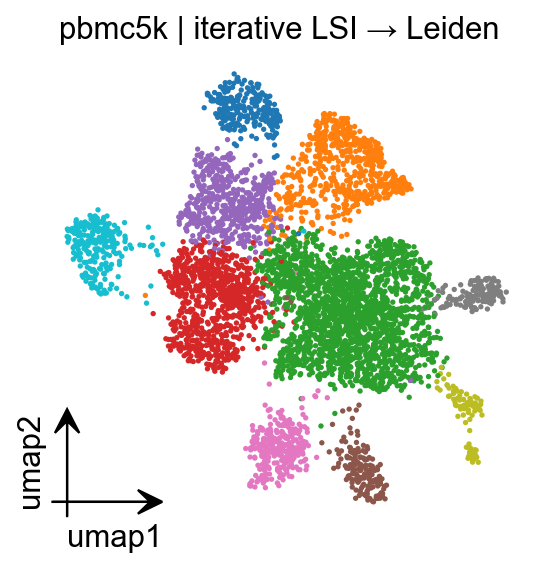

In [7]:
fig = epi.pl.umap(
    adata,
    color='leiden',
    legend_loc='on data',
    frameon=False,
    title='pbmc5k | iterative LSI → Leiden',
    return_fig=True,
    show=False,
)
fig


## Cross-check with ArchR

Below is a one-shot side-by-side on the ArchR hematopoiesis tutorial dataset (hg19). The R block is idempotent — it reuses cached inputs / project / embedding if already present and otherwise runs `addIterativeLSI` with ArchR's defaults. It is skipped automatically when ArchR is not installed.


In [8]:
import subprocess
RSCRIPT  = '/scratch/users/steorra/env/CMAP/bin/Rscript'
HEME     = pathlib.Path('/scratch/users/steorra/data/archr_heme')
ARCHR_OK = subprocess.run(
    [RSCRIPT, '-e', 'cat(requireNamespace("ArchR", quietly=TRUE))'],
    capture_output=True, text=True,
).stdout.strip().endswith('TRUE')
ARCHR_OK


True

In [9]:
if ARCHR_OK:
    HEME.mkdir(parents=True, exist_ok=True)
    (HEME / 'get_data.R').write_text(f'''
    suppressPackageStartupMessages({{ library(ArchR) }})
    set.seed(1); addArchRThreads(threads = 8); addArchRGenome("hg19")
    setwd("{HEME}")
    if (!file.exists("inputFiles.rds"))
      saveRDS(getTutorialData("Hematopoiesis"), "inputFiles.rds")
    ''')
    if not (HEME / 'inputFiles.rds').exists():
        subprocess.run([RSCRIPT, str(HEME / 'get_data.R')], check=True)

    (HEME / 'run_archr.R').write_text(f'''
    suppressPackageStartupMessages({{
      library(ArchR); library(Matrix); library(SummarizedExperiment); library(S4Vectors)
    }})
    set.seed(1); addArchRThreads(threads = 8); addArchRGenome("hg19")
    setwd("{HEME}")
    inputFiles <- readRDS("inputFiles.rds")
    inputFiles <- setNames(file.path("{HEME}", unname(inputFiles)),
                           names(inputFiles))
    if (!dir.exists("ArrowFiles")) dir.create("ArrowFiles")
    setwd("ArrowFiles")
    ArrowFiles <- createArrowFiles(
      inputFiles, names(inputFiles),
      minTSS = 4, minFrags = 1000,
      addTileMat = TRUE, addGeneScoreMat = FALSE, force = FALSE
    )
    setwd("..")
    if (!dir.exists("ArchR_proj")) {{
      proj <- ArchRProject(ArrowFiles, outputDirectory = "ArchR_proj", copyArrows = FALSE)
      proj <- addIterativeLSI(proj, useMatrix = "TileMatrix",
                              name = "IterativeLSI", iterations = 2,
                              varFeatures = 25000, dimsToUse = 1:30,
                              LSIMethod = 2, seed = 1, force = TRUE)
      saveArchRProject(proj)
    }} else proj <- loadArchRProject("ArchR_proj")
    emb <- getReducedDims(proj, "IterativeLSI")
    write.table(cbind(barcode = rownames(emb), as.data.frame(emb)),
                "archr_embedding.tsv", sep = "\t", quote = FALSE, row.names = FALSE)
    se  <- getMatrixFromProject(proj, useMatrix = "TileMatrix", binarize = TRUE)
    mat <- assay(se, "TileMatrix")
    writeMM(mat, "tile_matrix.mtx")
    writeLines(colnames(mat), "tile_barcodes.txt")
    rr  <- rowRanges(se)
    writeLines(paste0(seqnames(rr), ":", start(rr), "-", end(rr)), "tile_features.txt")
    ''')
    if not (HEME / 'archr_embedding.tsv').exists():
        subprocess.run([RSCRIPT, str(HEME / 'run_archr.R')], check=True)
    list(HEME.glob('*.tsv'))


### Load ArchR's tile matrix and run epione on the same counts


In [10]:
if ARCHR_OK:
    import scipy.io as sio
    mat  = sio.mmread(HEME / 'tile_matrix.mtx').tocsr()     # tiles × cells
    bc   = pd.read_csv(HEME / 'tile_barcodes.txt', header=None).iloc[:, 0].tolist()
    feat = pd.read_csv(HEME / 'tile_features.txt', header=None).iloc[:, 0].tolist()
    ad_archr = ad.AnnData(
        X=mat.T.tocsr(),
        obs=pd.DataFrame(index=bc),
        var=pd.DataFrame(index=feat),
    )
    ad_archr.obs['n_fragment'] = np.asarray(ad_archr.X.sum(axis=1)).ravel()
    ad_archr


In [11]:
%%time
if ARCHR_OK:
    epi.tl.iterative_lsi(
        ad_archr, n_components=30, iterations=2,
        var_features=25_000, resolution=2.0, n_neighbors=20,
        sample_cells_pre=10_000, depth_col='n_fragment', seed=1,
    )


  └─ [iterative_lsi] Initial feature set: 500,000 / 6,072,620


  └─ [iterative_lsi] Iter 1/2 | fit on 10,000 cells x 500,000 features


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)


running Leiden clustering


    finished: found 19 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


  └─ [iterative_lsi]   -> 19 clusters; selected 25,000 variable features for next round


  └─ [iterative_lsi] Iter 2/2 | fit on 10,660 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (10,660 x 29) in adata.obsm['X_iterative_lsi']
CPU times: user 2min 18s, sys: 4.48 s, total: 2min 22s
Wall time: 1min 25s


### Quantitative comparison

- **Procrustes disparity** — how well the two embeddings align after   an optimal rigid transform.
- **kNN overlap** — fraction of each cell's 20 nearest neighbours   shared between the two embeddings.
- **Leiden ARI** — cluster-label agreement.


In [12]:
if ARCHR_OK:
    from scipy.spatial import procrustes
    from sklearn.neighbors import NearestNeighbors
    from sklearn.metrics import adjusted_rand_score

    archr  = pd.read_csv(HEME / 'archr_embedding.tsv', sep='\t').set_index('barcode')
    common = ad_archr.obs_names.intersection(archr.index)
    A = ad_archr.obsm['X_iterative_lsi'][ad_archr.obs_names.get_indexer(common)]
    B = archr.loc[common].to_numpy()
    k = min(A.shape[1], B.shape[1]); A, B = A[:, :k], B[:, :k]

    _, _, disparity = procrustes(A, B)
    Na = NearestNeighbors(n_neighbors=20, metric='cosine').fit(A).kneighbors(A, return_distance=False)
    Nb = NearestNeighbors(n_neighbors=20, metric='cosine').fit(B).kneighbors(B, return_distance=False)
    overlap = np.mean([len(set(Na[i]) & set(Nb[i])) / Na.shape[1]
                       for i in range(A.shape[0])])

    tmp = ad_archr[list(common)].copy()
    tmp.obsm['X_epi']   = A
    tmp.obsm['X_archr'] = B
    def _clusters(key):
        sc.pp.neighbors(tmp, use_rep=key, key_added=key, n_neighbors=20)
        sc.tl.leiden(tmp, resolution=0.4, key_added='l_' + key,
                     neighbors_key=key, flavor='igraph', directed=False,
                     n_iterations=2, random_state=0)
        return tmp.obs['l_' + key]
    ari = adjusted_rand_score(_clusters('X_epi'), _clusters('X_archr'))

    print(f'shared cells           : {len(common):,}')
    print(f'Procrustes disparity   : {disparity:.3f}')
    print(f'kNN overlap (k=20)     : {overlap:.3f}')
    print(f'Leiden ARI             : {ari:.3f}')


computing neighbors


    finished: added to `.uns['X_epi']`
    `.obsp['X_epi_distances']`, distances for each pair of neighbors
    `.obsp['X_epi_connectivities']`, weighted adjacency matrix (0:00:08)


running Leiden clustering


    finished: found 5 clusters and added
    'l_X_epi', the cluster labels (adata.obs, categorical) (0:00:00)


computing neighbors


    finished: added to `.uns['X_archr']`
    `.obsp['X_archr_distances']`, distances for each pair of neighbors
    `.obsp['X_archr_connectivities']`, weighted adjacency matrix (0:00:01)


running Leiden clustering


    finished: found 9 clusters and added
    'l_X_archr', the cluster labels (adata.obs, categorical) (0:00:00)


shared cells           : 10,660
Procrustes disparity   : 0.713
kNN overlap (k=20)     : 0.101
Leiden ARI             : 0.610


## Notes

On the ArchR heme dataset we typically see Leiden ARI ≈ 0.6 and kNN overlap ≈ 0.1 — close cluster structure but distinct local neighbour sets. This is expected: both algorithms compute LSI on the same counts but differ in variable-feature selection (`highly_variable_genes`-style fixed-variance ranking vs ArchR's per-cluster means) and SVD implementations (randomized vs irlba). Downstream biology (cluster composition, UMAP topology) is effectively equivalent.
